# 🔍 Notebook 4 — Retrieval Pipeline (Phase 2)

هذا الـ notebook يشرح ويجرّب:
1. **Query normalization** — تنظيف السؤال
2. **Query expansion** — توليد بدائل
3. **Multi-turn context** — دمج سياق المحادثة
4. **Embedding the query** + البحث في Qdrant
5. **Re-ranking** (vector + lexical fusion)
6. **Confidence score** — كيف يُحسب؟
7. **Metadata filtering** — فلترة بالمجال/الصعوبة

> ⚠️ يحتاج: Qdrant شغّال + collection مبنية (run notebook 3 أو `scripts/ingest.py`)
---

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from app.config import get_settings
from app.rag.embeddings import E5Embedder
from app.rag.vector_store import QdrantVectorStore
from app.rag.query_processing import (
    normalize_query, expand_query, ConversationContext, contextualize_query
)
from app.rag.retriever import Retriever, _lexical_overlap

settings = get_settings()
embedder = E5Embedder(settings)
store    = QdrantVectorStore(settings, dimension=embedder.dimension)

print(f'Collection: {store.collection} — {store.count()} points')

c:\Users\EXPRESS\Anaconda3\envs\QA\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1964.97it/s]


Collection: natural_questions — 2040 points


c:\Users\EXPRESS\Anaconda3\envs\QA\Lib\site-packages\qdrant_client\qdrant_remote.py:282: UserWarning: Qdrant client version 1.18.0 is incompatible with server version 1.13.2. Major versions should match and minor version difference must not exceed 1. Set check_compatibility=False to skip version check.
  show_warning(


## 1. Query Normalization

In [2]:
test_queries = [
    "  Who had the most wins in the NFL?   ",
    "what is opt-in email marketing please",
    "Who is the mother in how i met your mother? thanks",
    "tell me  about  tom   brady",
]

print(f'{"Raw Query":<55} → {"Normalized"}')
print('─' * 100)
for q in test_queries:
    n = normalize_query(q)
    print(f'{repr(q):<55} → {repr(n)}')

Raw Query                                               → Normalized
────────────────────────────────────────────────────────────────────────────────────────────────────
'  Who had the most wins in the NFL?   '                → 'Who had the most wins in the NFL?'
'what is opt-in email marketing please'                 → 'what is opt-in email marketing'
'Who is the mother in how i met your mother? thanks'    → 'Who is the mother in how i met your mother?'
'tell me  about  tom   brady'                           → 'tell me about tom brady'


## 2. Query Expansion — توليد بدائل

In [3]:
expansion_tests = [
    "who directed the movie inception",
    "biggest country in the world by area",
    "when did the US declare independence",
    "who is the creator of python programming language",
    "best tv show of 2020",
]

for q in expansion_tests:
    variants = expand_query(q)
    print(f'\nOriginal : {q}')
    for i, v in enumerate(variants):
        prefix = 'Base   :' if i == 0 else f'Variant {i}:'
        marker = '' if i == 0 else '  ← expanded'
        print(f'  {prefix} {v}{marker}')


Original : who directed the movie inception
  Base   : who directed the movie inception
  Variant 1: who directed the film inception  ← expanded

Original : biggest country in the world by area
  Base   : biggest country in the world by area
  Variant 1: largest country in the world by area  ← expanded

Original : when did the US declare independence
  Base   : when did the US declare independence
  Variant 1: when did the usa declare independence  ← expanded
  Variant 2: when did the united states declare independence  ← expanded

Original : who is the creator of python programming language
  Base   : who is the creator of python programming language
  Variant 1: who is the inventor of python programming language  ← expanded
  Variant 2: who is the founder of python programming language  ← expanded

Original : best tv show of 2020
  Base   : best tv show of 2020
  Variant 1: best tv series of 2020  ← expanded
  Variant 2: best tv program of 2020  ← expanded


## 3. Multi-turn Context — سياق المحادثة

In [4]:
# محاكاة محادثة متعددة الأدوار
ctx = ConversationContext(max_turns=5)

print('── محادثة تجريبية ──')
turns = [
    ("Who is Tom Brady?",              "Tom Brady is an NFL quarterback known for his 7 Super Bowl titles."),
    ("How many wins does he have?",     "Tom Brady holds the record with 220 wins."),
    ("Which team did he start with?",   "He started his career with the New England Patriots."),
]

for user_q, assistant_a in turns:
    ctx.add(user_q, assistant_a)
    print(f'\nUser: {user_q}')
    print(f'Bot : {assistant_a[:80]}')

# سؤال متابعة قصير
followup = "and his jersey number?"
contextualized = contextualize_query(followup, ctx)

print(f'\n── Follow-up ──')
print(f'السؤال الأصلي  : {followup}')
print(f'بعد contextualize: {contextualized}')
print(f'(تم دمج السؤال السابق لأن السؤال قصير جداً وغامض)')

── محادثة تجريبية ──

User: Who is Tom Brady?
Bot : Tom Brady is an NFL quarterback known for his 7 Super Bowl titles.

User: How many wins does he have?
Bot : Tom Brady holds the record with 220 wins.

User: Which team did he start with?
Bot : He started his career with the New England Patriots.

── Follow-up ──
السؤال الأصلي  : and his jersey number?
بعد contextualize: Which team did he start with? and his jersey number?
(تم دمج السؤال السابق لأن السؤال قصير جداً وغامض)


In [5]:
# سؤال طويل لا يحتاج contextualize
standalone = "What are the health benefits of regular exercise according to medical research?"
contextualized2 = contextualize_query(standalone, ctx)

print(f'سؤال طويل مستقل: {standalone}')
print(f'بعد contextualize: {contextualized2}')
print(f'(لم يتغير — السؤال طويل ومستقل)')

سؤال طويل مستقل: What are the health benefits of regular exercise according to medical research?
بعد contextualize: What are the health benefits of regular exercise according to medical research?
(لم يتغير — السؤال طويل ومستقل)


## 4. البحث في Qdrant خطوة بخطوة

In [6]:
# ── الخطوة 1: نظّف وسعّ السؤال
raw_query = "who had the most wins in the NFL?"
normalized = normalize_query(raw_query)
variants   = expand_query(normalized)

print(f'المدخل   : {raw_query}')
print(f'بعد تنظيف: {normalized}')
print(f'البدائل  : {variants}')

المدخل   : who had the most wins in the NFL?
بعد تنظيف: who had the most wins in the NFL?
البدائل  : ['who had the most wins in the NFL?']


In [7]:
# ── الخطوة 2: تضمين كل بديل
query_vecs = embedder.embed(variants, task_type='RETRIEVAL_QUERY')
print(f'تم تضمين {len(query_vecs)} بديل، كل vector = {len(query_vecs[0])} بُعد')

تم تضمين 1 بديل، كل vector = 1024 بُعد


In [8]:
# ── الخطوة 3: Over-fetch ثم Fusion
TOP_K       = settings.top_k
CANDIDATE_K = TOP_K * settings.candidate_multiplier

fused = {}
for i, vec in enumerate(query_vecs):
    hits = store.search(vec, top_k=CANDIDATE_K)
    for hit in hits:
        existing = fused.get(hit.id)
        if existing is None or hit.score > existing.score:
            fused[hit.id] = hit

print(f'Over-fetch: {CANDIDATE_K} per variant × {len(query_vecs)} variants')
print(f'بعد fusion (إزالة المكرر): {len(fused)} مرشح فريد')

Over-fetch: 20 per variant × 1 variants
بعد fusion (إزالة المكرر): 20 مرشح فريد


In [10]:
# ── الخطوة 4: Re-ranking (vector + lexical)
from app.rag.retriever import RankedHit, _lexical_overlap

ranked_list = []
for hit in fused.values():
    vec_score = hit.score
    lex_score = _lexical_overlap(normalized, hit.text)
    final     = 0.82 * vec_score + 0.18 * lex_score
    ranked_list.append(RankedHit(hit, vec_score, lex_score, final))

ranked_list.sort(key=lambda r: r.final_score, reverse=True)
top_results = ranked_list[:TOP_K]

print(f'Top {TOP_K} نتائج بعد Re-ranking:\n')
print(f'{"#":<3} {"Vector":<8} {"Lexical":<8} {"Final":<8} {"Question"}')
print('─' * 80)
for i, r in enumerate(top_results, 1):
    q = r.payload.get('question','')[:50]
    print(f'{i:<3} {r.vector_score:<8.4f} {r.lexical_score:<8.4f} {r.final_score:<8.4f} {q}')

Top 5 نتائج بعد Re-ranking:

#   Vector   Lexical  Final    Question
────────────────────────────────────────────────────────────────────────────────
1   0.8897   1.0000   0.9096   who had the most wins in the nfl
2   0.8616   0.8571   0.8608   who has won the most super bowl championships
3   0.8575   0.8571   0.8574   who has won the most super bowl championships
4   0.8186   0.7143   0.7999   how many super bowl wins do giants have
5   0.8043   0.7143   0.7881   who won the college football national championship


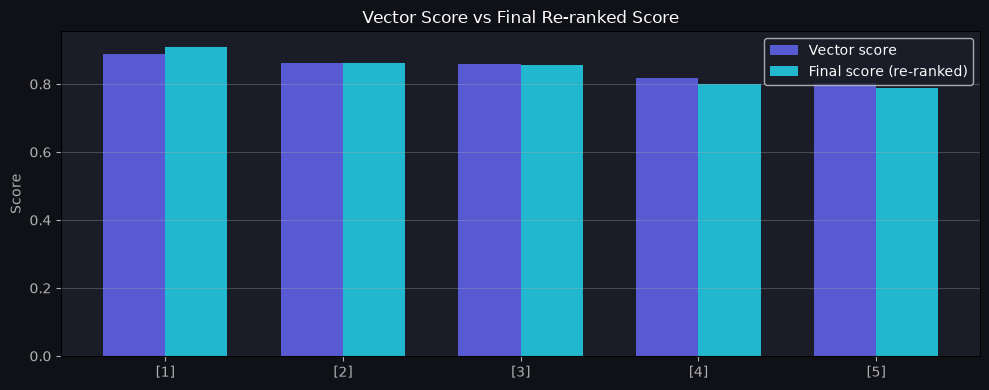

In [11]:
# رسم مقارنة Vector score vs Final score
if top_results:
    labels = [f'[{i+1}]' for i in range(len(top_results))]
    vec_scores   = [r.vector_score  for r in top_results]
    final_scores = [r.final_score   for r in top_results]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 4), facecolor='#0f1117')
    ax.set_facecolor('#1a1d27')
    ax.bar(x - width/2, vec_scores,   width, label='Vector score', color='#6366f1', alpha=0.85)
    ax.bar(x + width/2, final_scores, width, label='Final score (re-ranked)', color='#22d3ee', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, color='#b0b0b0')
    ax.set_ylabel('Score', color='#b0b0b0')
    ax.set_title('Vector Score vs Final Re-ranked Score', color='white')
    ax.legend(facecolor='#1a1d27', labelcolor='white')
    ax.tick_params(colors='#b0b0b0')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

## 5. Confidence Score — كيف يُحسب؟

أعلى final score : 0.9096
Confidence       : 0.9636 (96.4%)
Min confidence   : 0.3 (Fallback threshold)
Will fallback?   : False


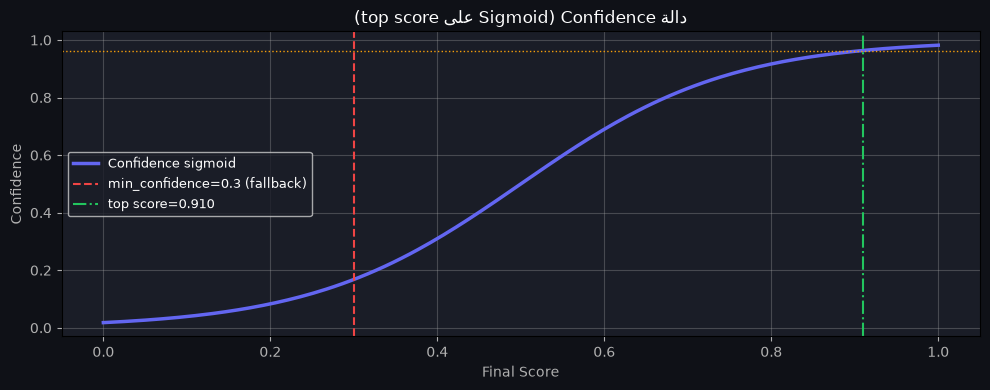

In [12]:
from app.rag.retriever import Retriever

conf = Retriever.confidence(top_results)
print(f'أعلى final score : {top_results[0].final_score:.4f}')
print(f'Confidence       : {conf:.4f} ({conf*100:.1f}%)')
print(f'Min confidence   : {settings.min_confidence} (Fallback threshold)')
print(f'Will fallback?   : {conf < settings.min_confidence}')

# رسم دالة sigmoid للـ confidence
scores = np.linspace(0, 1, 200)
confs  = 1 / (1 + np.exp(-8 * (scores - 0.5)))

fig, ax = plt.subplots(figsize=(10, 4), facecolor='#0f1117')
ax.set_facecolor('#1a1d27')
ax.plot(scores, confs, color='#6366f1', lw=2.5, label='Confidence sigmoid')
ax.axvline(settings.min_confidence, color='#ef4444', lw=1.5, linestyle='--',
           label=f'min_confidence={settings.min_confidence} (fallback)')
ax.axvline(top_results[0].final_score, color='#22c55e', lw=1.5, linestyle='-.',
           label=f'top score={top_results[0].final_score:.3f}')
ax.axhline(conf, color='#f59e0b', lw=1, linestyle=':')
ax.set_xlabel('Final Score', color='#b0b0b0')
ax.set_ylabel('Confidence', color='#b0b0b0')
ax.set_title('دالة Confidence (Sigmoid على top score)', color='white')
ax.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)
ax.tick_params(colors='#b0b0b0')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. استخدام Retriever بشكل مباشر

In [13]:
retriever = Retriever(embedder, store, settings)

# جرّب سؤال مختلف
MY_QUERY = "who is the mother in how i met your mother"
ranked = retriever.retrieve(MY_QUERY, top_k=5)
conf   = Retriever.confidence(ranked)

print(f'Query: {MY_QUERY}')
print(f'Confidence: {conf:.4f}\n')
print(f'{"#":<3} {"Score":<8} {"Domain":<14} {"Type":<12} {"Question"}')
print('─' * 85)
for i, r in enumerate(ranked, 1):
    p = r.payload
    print(f'{i:<3} {r.final_score:<8.4f} {p.get("domain",""):<14} '
          f'{p.get("question_type",""):<12} {p.get("question","")[:45]}')
print()
print('أفضل إجابة مسترجعة:')
print(ranked[0].payload.get('long_answer', ranked[0].text)[:500])

Query: who is the mother in how i met your mother
Confidence: 0.9593

#   Score    Domain         Type         Question
─────────────────────────────────────────────────────────────────────────────────────
1   0.8949   entertainment  person       who is.the mother in how i met your mother
2   0.8913   entertainment  boolean      how i.met your mother who is the mother
3   0.8616   entertainment  boolean      what season do you meet ted's wife
4   0.8478   entertainment  factual      who plays zoe on how i met your mother
5   0.7652   entertainment  factual      who plays spencer's mother in pretty little l

أفضل إجابة مسترجعة:
Tracy McConnell, better known as " The Mother ", is the title character from the CBS television sitcom How I Met Your Mother. The show, narrated by Future Ted, tells the story of how Ted Cosby met The Mother. Tracy McConnell appears in episodes from " Lucky Penny " to " The Time Travelers " as an unseen character; she was first seen fully in " Something New " and

## 7. Metadata Filtering — فلترة بالمجال

In [14]:
# نفس السؤال مع وبدون فلتر
q = "who won the championship"

print('بدون فلتر:')
r_no_filter = retriever.retrieve(q, top_k=3, filters=None)
for r in r_no_filter:
    print(f'  score={r.final_score:.3f} domain={r.payload.get("domain"):12} {r.payload.get("question","")[:50]}')

print('\nمع فلتر domain=sports:')
r_sports = retriever.retrieve(q, top_k=3, filters={'domain': 'sports'})
for r in r_sports:
    print(f'  score={r.final_score:.3f} domain={r.payload.get("domain"):12} {r.payload.get("question","")[:50]}')

print('\nمع فلتر difficulty=easy:')
r_easy = retriever.retrieve(q, top_k=3, filters={'difficulty': 'easy'})
for r in r_easy:
    print(f'  score={r.final_score:.3f} diff={r.payload.get("difficulty"):8} {r.payload.get("question","")[:50]}')

بدون فلتر:
  score=0.869 domain=sports       who won the college football national championship
  score=0.844 domain=sports       who has won the most games in world cup 2018
  score=0.843 domain=sports       who has won the most formula 1 world championships

مع فلتر domain=sports:
  score=0.869 domain=sports       who won the college football national championship
  score=0.844 domain=sports       who has won the most games in world cup 2018
  score=0.843 domain=sports       who has won the most formula 1 world championships

مع فلتر difficulty=easy:
  score=0.805 diff=easy     who won the all ireland football final 2017
  score=0.797 diff=easy     when was the last time a detroit sports team won a
  score=0.795 diff=easy     who won between oscar de la hoya and floyd mayweat
